In [1]:

from google.colab import drive
drive.mount('/content/drive')


ModuleNotFoundError: No module named 'google'

In [55]:
!pip install tensorflow opencv-python scikit-learn matplotlib seaborn albumentations

In [56]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [57]:
IMAGE_SIZE = 120
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50


In [64]:
DATASET_PATH = "/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/raw/paddy-disease-classification/train_images"
EDA_DIR = Path("/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/eda_visualizations")
OUTPUTS_DIR = Path("/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/outputs")

EDA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)



In [66]:
# === Load dataset ===
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)
class_names = dataset.class_names
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 14990 files belonging to 8 classes.
Classes: ['bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Number of classes: 8


In [67]:
# === Partition function ===
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1,
                              shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    return train_ds, val_ds, test_ds


In [69]:
# === Split dataset ===
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Train batches: 375
Validation batches: 46
Test batches: 48


In [70]:
# === Save split counts ===
split_counts = {
    "train_batches": len(train_ds),
    "validation_batches": len(val_ds),
    "test_batches": len(test_ds),
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE
}

In [71]:
pd.DataFrame([split_counts]).to_csv(OUTPUTS_DIR / "dataset_split_counts.csv", index=False)
print(" Saved dataset split counts to outputs/")

 Saved dataset split counts to outputs/


 Saved figure: /content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/eda_visualizations/dataset_split_piechart.png


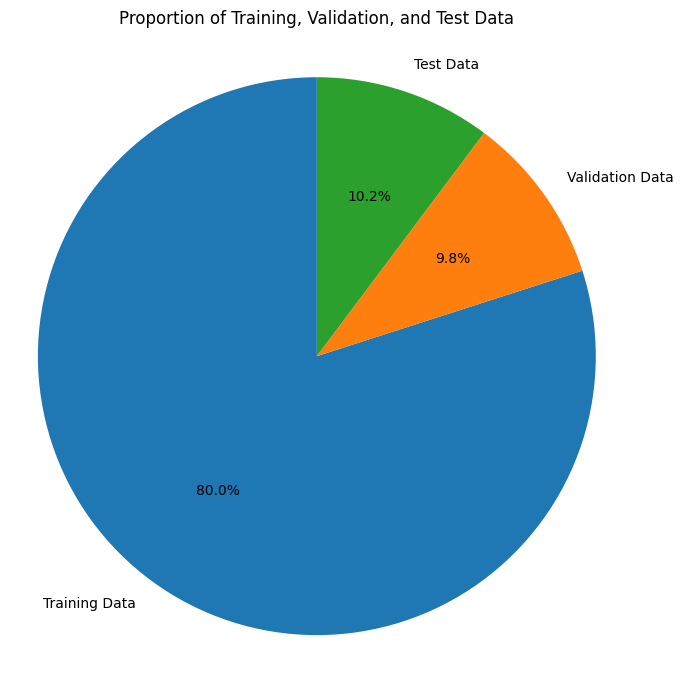

In [72]:
# === Visualization ===
labels = ['Training Data', 'Validation Data', 'Test Data']
sizes = [len(train_ds), len(val_ds), len(test_ds)]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title("Proportion of Training, Validation, and Test Data")
plt.axis('equal')

savefig("dataset_split_piechart")
plt.show()